In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('Enaho01-2024-100.csv', 
                encoding='latin-1', 
                skipinitialspace=True, 
                low_memory=False)
display(df.shape)
display(df.head())

(44731, 338)

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,DOMINIO,UBIGEO,ESTRATO,PERIODO,TIPENC,...,NBI4,NBI5,FACTOR07,NCONGLOME,SUB_CONGLOME,CODCCPP,NOMCCPP,LONGITUD,LATITUD,ALTITUD
0,2024,9,15006,13,11,4,10101,4,2,1,...,0.0,0.0,112.074959,7071,1,1,ASENTAMIENTO HUMANO PEDRO CASTRO ALVA,-77.865566,-6.213714,2420.432676
1,2024,9,15006,27,11,4,10101,4,2,1,...,0.0,0.0,112.074959,7071,1,1,ASENTAMIENTO HUMANO PEDRO CASTRO ALVA,-77.865566,-6.213714,2420.432676
2,2024,9,15006,50,11,4,10101,4,2,1,...,0.0,0.0,112.074959,7071,1,1,ASENTAMIENTO HUMANO PEDRO CASTRO ALVA,-77.865566,-6.213714,2420.432676
3,2024,9,15006,64,11,4,10101,4,2,1,...,0.0,0.0,112.074959,7071,1,1,ASENTAMIENTO HUMANO PEDRO CASTRO ALVA,-77.865566,-6.213714,2420.432676
4,2024,9,15006,76,11,4,10101,4,2,1,...,0.0,0.0,112.074959,7071,1,1,ASENTAMIENTO HUMANO PEDRO CASTRO ALVA,-77.865566,-6.213714,2420.432676


In [15]:
#FILTRAMOS LOS REGISROS

#Filtramos los registros completos (completaron la encuesta)
df = df[df['RESULT'].isin([1, 2])]

#Filtramos los registros pertenecientes a Lima y Callao (UBIGEO 15 y 07)
df['UBIGEO'] = df['UBIGEO'].astype(str).str.zfill(6)
df = df[df['UBIGEO'].str.startswith(('07', '15'))]


display(df.shape)
display(df.head())

(5571, 338)

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,DOMINIO,UBIGEO,ESTRATO,PERIODO,TIPENC,...,NBI4,NBI5,FACTOR07,NCONGLOME,SUB_CONGLOME,CODCCPP,NOMCCPP,LONGITUD,LATITUD,ALTITUD
10165,2024,12,16184,112,11,8,070101,1,3,1,...,0.0,0.0,289.513550,18445,0,1,AA HH BAQUIJANO,-77.113699,-12.048521,30.556653
10166,2024,2,16256,6,11,8,070101,1,2,1,...,0.0,0.0,600.870789,17984,0,1,AA HH VERRA,-77.117297,-11.989514,19.241812
10167,2024,5,16242,42,11,8,070101,1,1,1,...,0.0,0.0,606.707275,18045,0,1,AAHHH SARITA COLONIA,-77.134933,-12.024632,5.951253
10168,2024,4,16285,82,11,8,070101,1,3,3,...,0.0,0.0,408.504822,18218,0,1,ASENTAMIEMTO HUMANO TODOS UNIDOS,-77.103352,-12.041538,40.135738
10169,2024,6,16201,144,11,8,070101,1,1,1,...,0.0,0.0,140.608948,18070,0,1,ASENTAMIENTO DE BOCA NEGRA,-77.103394,-12.022166,35.885811


In [16]:
#FILTRAMOS LAS COLUMNAS

colums_valid_names = {
    'CONGLOME' : 'conglomerado',
    'VIVIENDA' : 'vivienda',
    'HOGAR' : 'hogar', 
    'P103' : 'material_piso', 
    'P102' : 'material_pared_exterior',
    'P110' : 'fuente_agua', 
    'P111A' : 'conexion_bano', 
    'P113A' : 'combustible_cocina', 
    'P104' : 'total_habitaciones',
    'P104A' : 'total_dormitorios',
    'P105A' : 'tenencia_vivienda', 
    'P106A' : 'titulo_propiedad',
    'P106B' : 'registro_sunarp', 
    'NBI1' : 'vivienda_inadecuada',
    'NBI2' : 'vivienda_hacinamiento',
    'NBI3' : 'vivienda_sin_bano',
    'NBI4' : 'nino_sin_educacion',
    'NBI5' : 'dependencia_economica'
}

df = df[colums_valid_names.keys()]
df = df.rename(columns=colums_valid_names)
df.set_index(['conglomerado', 'vivienda', 'hogar'], inplace=True)

display(df.shape)
display(df.head(20))

(5571, 15)

material_piso  material_pared_exterior  \
conglomerado vivienda hogar                                           
16184        112      11               3.0                      1.0   
16256        6        11               5.0                      1.0   
16242        42       11               5.0                      1.0   
16285        82       11               3.0                      1.0   
16201        144      11               5.0                      1.0   
             34       11               1.0                      1.0   
             78       11               3.0                      1.0   
             187      11               5.0                      1.0   
             232      11               5.0                      1.0   
16215        28       11               5.0                      1.0   
             51       11               3.0                      1.0   
             64       11               3.0                      1.0   
16172        110      13               5.0                      1.0   
                      33               NaN                      NaN   
16316        138      11               5.0                      7.0   
16253        165      11               3.0                      1.0   
16313        84       11               5.0                      1.0   
             181      11               3.0                      1.0   
16316        17       11               6.0                      7.0   
             37       11               5.0                      7.0   

                             fuente_agua  conexion_bano  combustible_cocina  \
conglomerado vivienda hogar                                                   
16184        112      11             1.0            1.0                 3.0   
16256        6        11             1.0            1.0                 2.0   
16242        42       11             1.0            1.0                 2.0   
16285        82       11             1.0            1.0                 2.0   
16201        144      11             1.0            1.0                 2.0   
             34       11             1.0            1.0                 3.0   
             78       11             1.0            1.0                 2.0   
             187      11             1.0            1.0                 3.0   
             232      11             1.0            1.0                 3.0   
16215        28       11             2.0            2.0                 2.0   
             51       11             1.0            1.0                 2.0   
             64       11             1.0            1.0                 2.0   
16172        110      13             1.0            1.0                 2.0   
                      33             1.0            1.0                 2.0   
16316        138      11             1.0            1.0                 1.0   
16253        165      11             1.0            1.0                 3.0   
16313        84       11             1.0            1.0                 3.0   
             181      11             1.0            1.0                 2.0   
16316        17       11             1.0            1.0                 2.0   
             37       11             3.0            1.0                 2.0   

                             total_habitaciones  total_dormitorios  \
conglomerado vivienda hogar                                          
16184        112      11                    3.0                2.0   
16256        6        11                    4.0                3.0   
16242        42       11                    3.0                2.0   
16285        82       11                    1.0                0.0   
16201        144      11                    2.0                1.0   
             34       11                    4.0                3.0   
             78       11                    2.0                1.0   
             187      11                    3.0                2.0   
             232      11   

In [17]:
# VALORES DE LOS DATOS

colums_valid_names = {
    'conglomerado': None,
    'vivienda': None,
    'hogar': None,
    
    # P103
    'material_piso': {
        1: 'parquet',
        2: 'vinilico',
        3: 'loseta',
        4: 'madera',
        5: 'cemento',
        6: 'tierra',
        7: 'otro'
    },
    
    # P102
    'material_pared_exterior': {
        1: 'ladrillo',
        2: 'piedra_cemento',
        3: 'adobe',
        4: 'tapia',
        5: 'quincha',
        6: 'piedra_barro',
        7: 'madera',
        8: 'triplay_calamina',
        9: 'otro'
    },
    
    # P110
    'fuente_agua': {
        1: 'red_interior',
        2: 'red_exterior',
        3: 'pilon',
        4: 'cisterna',
        5: 'pozo',
        6: 'manantial',
        7: 'otro',
        8: 'rio_laguna'
    },
    
    # P111A
    'conexion_bano': {
        1: 'desague_interior',
        2: 'desague_exterior',
        3: 'letrina',
        4: 'pozo_septico',
        5: 'pozo_ciego',
        6: 'rio_canal',
        7: 'otro',
        9: 'campo_abierto'
    },
    
    # P113A
    'combustible_cocina': {
        1: 'electricidad',
        2: 'gas_glp',
        3: 'gas_natural',
        5: 'carbon',
        6: 'lena',
        7: 'otro',
        8: 'no_cocina'
    },
    
    'total_habitaciones': None,
    'total_dormitorios': None,
    
    # P105A
    'tenencia_vivienda': {
        1: 'alquilada',
        2: 'propia_pagada',
        3: 'propia_invasion',
        4: 'propia_plazos',
        5: 'cedida_trabajo',
        6: 'cedida_otro',
        7: 'otro'
    },
    
    # P106A
    'titulo_propiedad': {
        1: 'si',
        2: 'no',
        3: 'en_tramite'
    },
    
    # P106B
    'registro_sunarp': {
        1: 'si',
        2: 'no'
    },
    
    # NBI1 a NBI5 (0: adecuado / no padece, 1: carencia / insatisfecha)
    'vivienda_inadecuada': {
        0: 'adecuada',
        1: 'inadecuada'
    },
    'vivienda_hacinamiento': {
        0: 'no_hacinada',
        1: 'hacinada'
    },
    'vivienda_sin_bano': {
        0: 'con_bano',
        1: 'sin_bano'
    },
    'nino_sin_educacion': {
        0: 'asiste',
        1: 'no_asiste'
    },
    'dependencia_economica': {
        0: 'baja_dependencia',
        1: 'alta_dependencia'
    }
}

for col, mapping in colums_valid_names.items():
    if mapping and col in df.columns:
        df[col] = df[col].map(mapping)

display(df.shape)
display(df.head(20))

(5571, 15)

material_piso material_pared_exterior  \
conglomerado vivienda hogar                                         
16184        112      11           loseta                ladrillo   
16256        6        11          cemento                ladrillo   
16242        42       11          cemento                ladrillo   
16285        82       11           loseta                ladrillo   
16201        144      11          cemento                ladrillo   
             34       11          parquet                ladrillo   
             78       11           loseta                ladrillo   
             187      11          cemento                ladrillo   
             232      11          cemento                ladrillo   
16215        28       11          cemento                ladrillo   
             51       11           loseta                ladrillo   
             64       11           loseta                ladrillo   
16172        110      13          cemento                ladrillo   
                      33              NaN                     NaN   
16316        138      11          cemento                  madera   
16253        165      11           loseta                ladrillo   
16313        84       11          cemento                ladrillo   
             181      11           loseta                ladrillo   
16316        17       11           tierra                  madera   
             37       11          cemento                  madera   

                              fuente_agua     conexion_bano  \
conglomerado vivienda hogar                                   
16184        112      11     red_interior  desague_interior   
16256        6        11     red_interior  desague_interior   
16242        42       11     red_interior  desague_interior   
16285        82       11     red_interior  desague_interior   
16201        144      11     red_interior  desague_interior   
             34       11     red_interior  desague_interior   
             78       11     red_interior  desague_interior   
             187      11     red_interior  desague_interior   
             232      11     red_interior  desague_interior   
16215        28       11     red_exterior  desague_exterior   
             51       11     red_interior  desague_interior   
             64       11     red_interior  desague_interior   
16172        110      13     red_interior  desague_interior   
                      33     red_interior  desague_interior   
16316        138      11     red_interior  desague_interior   
16253        165      11     red_interior  desague_interior   
16313        84       11     red_interior  desague_interior   
             181      11     red_interior  desague_interior   
16316        17       11     red_interior  desague_interior   
             37       11            pilon  desague_interior   

                            combustible_cocina  total_habitaciones  \
conglomerado vivienda hogar                                          
16184        112      11           gas_natural                 3.0   
16256        6        11               gas_glp                 4.0   
16242        42       11               gas_glp                 3.0   
16285        82       11               gas_glp                 1.0   
16201        144      11               gas_glp                 2.0   
             34       11           gas_natural                 4.0   
             78       11               gas_glp                 2.0   
             187      11           gas_natural                 3.0   
             232      11           gas_natural                 3.0   
16215        28       11               gas_glp                 2.0   
             51       11               gas_glp                 3.0   
             64       11               gas_glp                 3.0   
16172        110      13               gas_glp                11.0   
                      33               gas_glp                 NaN   
16

In [18]:
display(df.isnull().sum())
display(df.isnull().mean()*100)

material_piso               106
material_pared_exterior     106
fuente_agua                   0
conexion_bano                 0
combustible_cocina           78
total_habitaciones          106
total_dormitorios           106
tenencia_vivienda             0
titulo_propiedad           1764
registro_sunarp            3151
vivienda_inadecuada           0
vivienda_hacinamiento         0
vivienda_sin_bano             0
nino_sin_educacion            0
dependencia_economica         0
dtype: int64

material_piso               1.902710
material_pared_exterior     1.902710
fuente_agua                 0.000000
conexion_bano               0.000000
combustible_cocina          1.400108
total_habitaciones          1.902710
total_dormitorios           1.902710
tenencia_vivienda           0.000000
titulo_propiedad           31.663974
registro_sunarp            56.560761
vivienda_inadecuada         0.000000
vivienda_hacinamiento       0.000000
vivienda_sin_bano           0.000000
nino_sin_educacion          0.000000
dependencia_economica       0.000000
dtype: float64

In [19]:
str_cols = df.select_dtypes(include=['str']).columns.tolist()
df[str_cols] = df[str_cols].astype('category')

df_numeric = df.select_dtypes(include=np.number)
df_category = df.select_dtypes(include='category')

In [20]:
display(df_numeric.describe())
display(df_category.describe())

,total_habitaciones,total_dormitorios
count,5465.000000,5465.000000
mean,3.433669,2.215371
std,1.521575,1.141964
min,1.000000,0.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,3.000000
max,14.000000,10.000000


,material_piso,material_pared_exterior,fuente_agua,conexion_bano,combustible_cocina,tenencia_vivienda,titulo_propiedad,registro_sunarp,vivienda_inadecuada,vivienda_hacinamiento,vivienda_sin_bano,nino_sin_educacion,dependencia_economica
count,5465,5465,5571,5571,5493,5571,3807,2420,5571,5571,5571,5571,5571
unique,7,9,8,8,6,7,3,2,2,2,2,2,2
top,cemento,ladrillo,red_interior,desague_interior,gas_glp,propia_pagada,si,si,adecuada,no_hacinada,con_bano,asiste,baja_dependencia
freq,2711,4168,4869,4666,3266,3451,2421,2241,5371,5406,5426,5551,5557


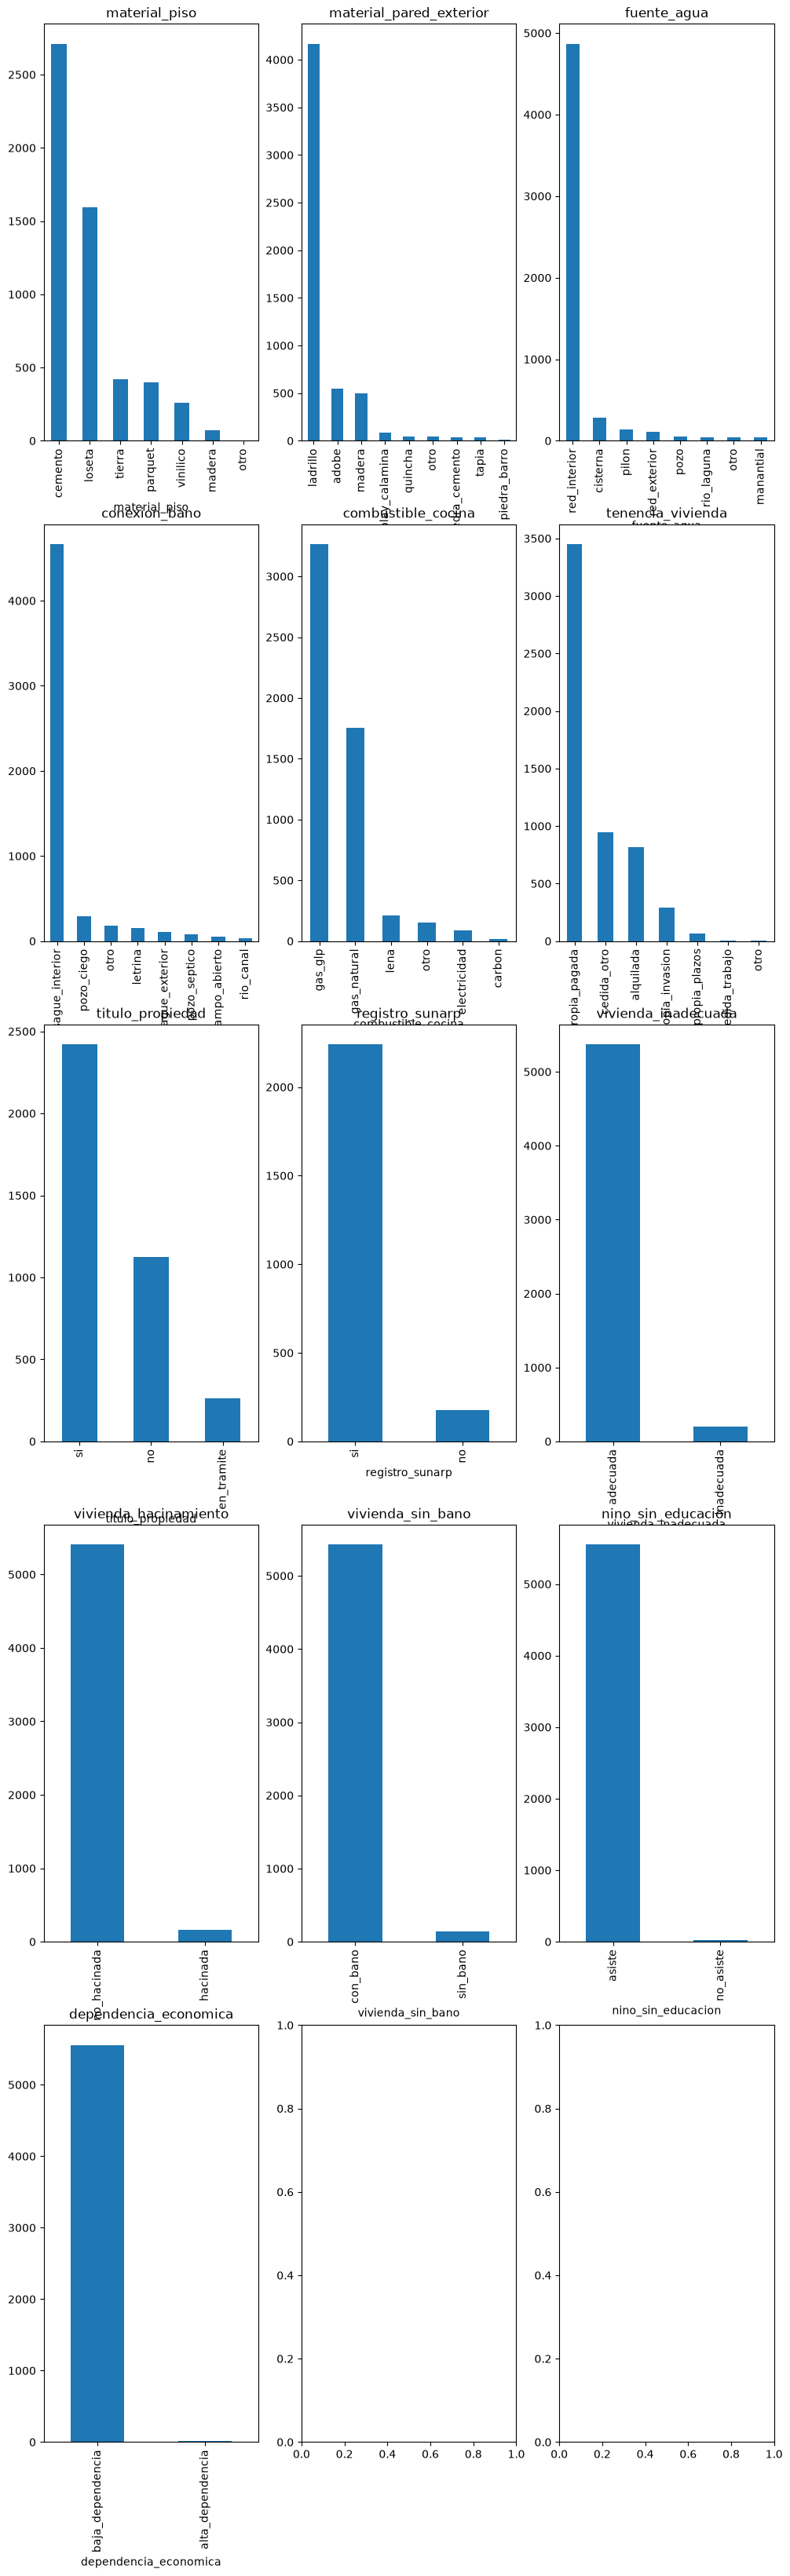

In [21]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 40))
axes = axes.flatten()
for i, col in enumerate(df.select_dtypes(include='category').columns):
    df[col].value_counts().plot(kind='bar', ax=axes[i], title=col)

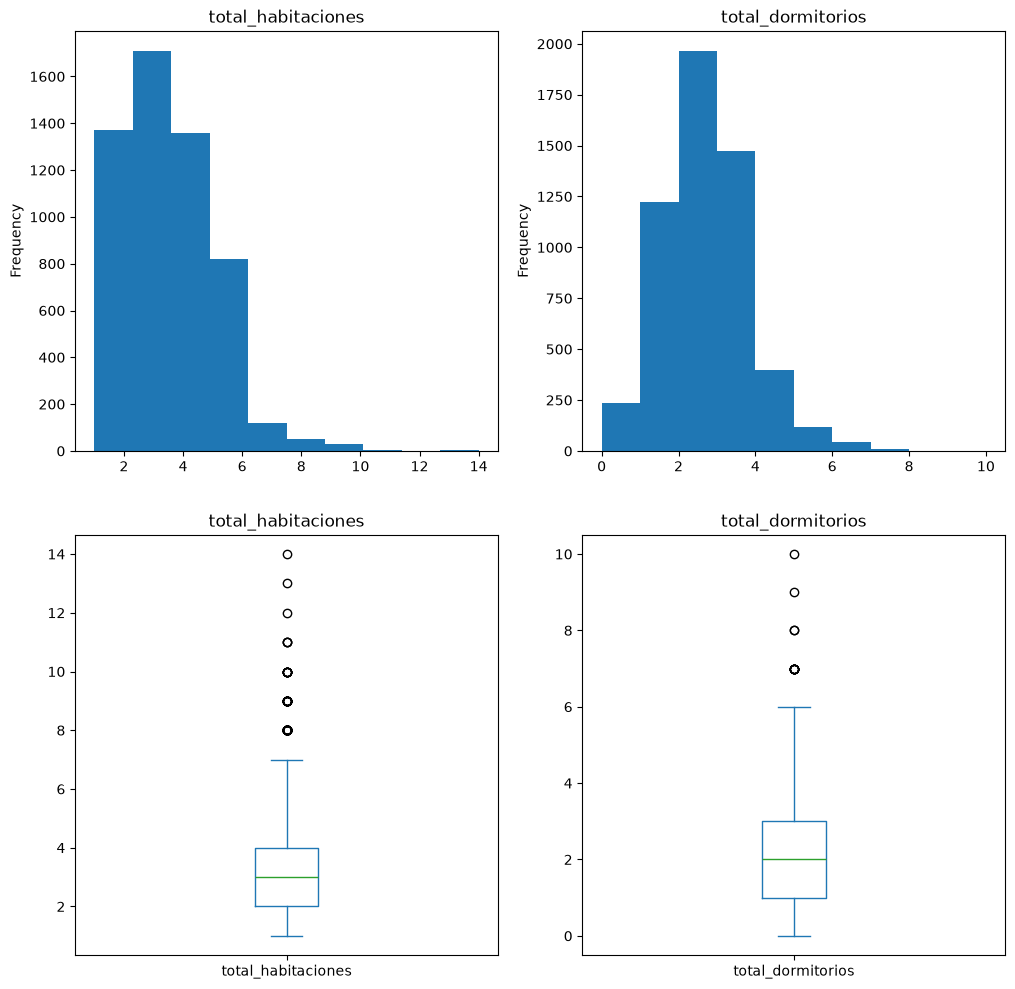

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axes = axes.flatten()
for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    df[col].plot(kind='hist', ax=axes[i], title=col)
    df[col].plot(kind='box', ax=axes[i+2], title=col)
    

In [23]:
df[df.select_dtypes(include='category').columns].value_counts()

material_piso  material_pared_exterior  fuente_agua   conexion_bano     combustible_cocina  tenencia_vivienda  titulo_propiedad  registro_sunarp  vivienda_inadecuada  vivienda_hacinamiento  vivienda_sin_bano  nino_sin_educacion  dependencia_economica
loseta         ladrillo                 red_interior  desague_interior  gas_glp             propia_pagada      si                si               adecuada             no_hacinada            con_bano           asiste              baja_dependencia         375
                                                                        gas_natural         propia_pagada      si                si               adecuada             no_hacinada            con_bano           asiste              baja_dependencia         345
cemento        ladrillo                 red_interior  desague_interior  gas_natural         propia_pagada      si                si               adecuada             no_hacinada            con_bano           asiste              baja

In [24]:
df.to_csv('Enaho01-2024-100_cleaned.csv')